We need information representing how strong Argentina and France were before the match.

# FIFA World Cup Predictor
## Notebook 2 — Feature Engineering and Exploratory Data Analysis

This notebook transforms the cleaned historical men's tournament dataset
into a modeling dataset.

The objective is to create pre-match predictors representing team strength
and recent performance while avoiding temporal data leakage.

Features include:

- Elo rating
- Recent form
- Recent goals scored
- Recent goals conceded
- Recent goal difference
- Recent win rate
- Match experience
- Knockout-stage indicator

All features are calculated using information available before each match.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from collections import defaultdict, deque

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving matches_men_clean.csv to matches_men_clean.csv


In [ ]:
matches_men = pd.read_csv(
    "matches_men_clean.csv"
)

print("Dataset loaded.")
print("Shape:", matches_men.shape)

display(matches_men.head())

Dataset loaded.
Shape: (358, 17)


,date,tournament,year,round,team_a,team_b,score_a,score_b,ft_goals1,ft_goals2,penalty1,penalty2,result,group,ground,total_goals,goal_difference
0,6/11/2010,World Cup,2010,Matchday 1,South Africa,Mexico,1,1,1,1,NaN,NaN,Draw,Group A,"Soccer City, Johannesburg",2,0
1,6/11/2010,World Cup,2010,Matchday 1,Uruguay,France,0,0,0,0,NaN,NaN,Draw,Group A,"Cape Town Stadium, Cape Town",0,0
2,6/16/2010,World Cup,2010,Matchday 6,South Africa,Uruguay,0,3,0,3,NaN,NaN,Team B Win,Group A,"Loftus Versfeld Stadium, Pretoria",3,-3
3,6/17/2010,World Cup,2010,Matchday 7,France,Mexico,0,2,0,2,NaN,NaN,Team B Win,Group A,"Peter Mokaba Stadium, Polokwane",2,-2
4,6/22/2010,World Cup,2010,Matchday 12,Mexico,Uruguay,0,1,0,1,NaN,NaN,Team B Win,Group A,"Royal Bafokeng Stadium, Rustenburg",1,-1


In [ ]:
required_columns = [
    "date",
    "tournament",
    "year",
    "round",
    "team_a",
    "team_b",
    "score_a",
    "score_b",
    "ft_goals1",
    "ft_goals2",
    "pen1",
    "pen2",
    "result",
    "group",
    "ground",
    "total_goals",
    "goal_difference"
]

missing_columns = [
    col for col in required_columns
    if col not in matches_men.columns
]

if missing_columns:
    print("Missing columns:")
    print(missing_columns)
else:
    print("All required columns are present.")

Missing columns:
['pen1', 'pen2']


In [ ]:
matches_men["date"] = pd.to_datetime(
    matches_men["date"]
)

matches_men = (
    matches_men
    .sort_values(["date", "year"])
    .reset_index(drop=True)
)

print("First match:")
display(matches_men.head(1))

print("\nLast match:")
display(matches_men.tail(1))

First match:


,date,tournament,year,round,team_a,team_b,score_a,score_b,ft_goals1,ft_goals2,penalty1,penalty2,result,group,ground,total_goals,goal_difference
0,2010-06-11,World Cup,2010,Matchday 1,South Africa,Mexico,1,1,1,1,NaN,NaN,Draw,Group A,"Soccer City, Johannesburg",2,0



Last match:


,date,tournament,year,round,team_a,team_b,score_a,score_b,ft_goals1,ft_goals2,penalty1,penalty2,result,group,ground,total_goals,goal_difference
357,2024-07-14,European Championship,2024,Final,Spain,England,2,1,2,1,NaN,NaN,Team A Win,NaN,Berlin,3,1


In [ ]:
print(
    "Dates sorted correctly:",
    matches_men["date"].is_monotonic_increasing
)

print(
    "Date range:",
    matches_men["date"].min(),
    "to",
    matches_men["date"].max()
)

Dates sorted correctly: True
Date range: 2010-06-11 00:00:00 to 2024-07-14 00:00:00


In [ ]:
result_mapping = {
    "Team B Win": 0,
    "Draw": 1,
    "Team A Win": 2
}

matches_men["target"] = (
    matches_men["result"]
    .map(result_mapping)
)

print(matches_men["result"].value_counts())

print("\nEncoded target:")
print(matches_men["target"].value_counts().sort_index())

result
Team A Win    142
Team B Win    130
Draw           86
Name: count, dtype: int64

Encoded target:
target
0    130
1     86
2    142
Name: count, dtype: int64


In [ ]:
target_check = pd.DataFrame({
    "result": matches_men["result"],
    "target": matches_men["target"]
})

display(
    target_check
    .drop_duplicates()
    .sort_values("target")
)

,result,target
5,Team B Win,0
0,Draw,1
2,Team A Win,2


In [ ]:
matches_men["poisson_goals_a"] = (
    matches_men["ft_goals1"]
)

matches_men["poisson_goals_b"] = (
    matches_men["ft_goals2"]
)

print(
    "Average Team A goals:",
    round(matches_men["poisson_goals_a"].mean(), 3)
)

print(
    "Average Team B goals:",
    round(matches_men["poisson_goals_b"].mean(), 3)
)

Average Team A goals: 1.291
Average Team B goals: 1.201


In [ ]:
matches_men["is_knockout"] = (
    matches_men["group"].isna()
).astype(int)

print(
    matches_men["is_knockout"]
    .value_counts()
)

print("\n0 = Group stage")
print("1 = Knockout stage")

is_knockout
0    264
1     94
Name: count, dtype: int64

0 = Group stage
1 = Knockout stage


In [ ]:
print(
    matches_men["round"]
    .value_counts()
)

round
Round of 16              48
Matchday 3               39
Matchday 2               36
Matchday 1               29
Quarter-finals           20
Matchday 13              16
Matchday 12              16
Matchday 4               13
Matchday 8               13
Matchday 7               13
Matchday 6               13
Matchday 5               13
Matchday 11              13
Matchday 10              13
Matchday 9               13
Matchday 14              12
Matchday 15              12
Semi-finals               8
Final                     6
Quarterfinals             4
Match for third place     3
Semifinals                2
Semi-final                2
Third-place play-off      1
Name: count, dtype: int64


In [ ]:
knockout_keywords = [
    "round of 16",
    "round of 32",
    "quarter",
    "semi",
    "final",
    "third place",
    "play-off",
    "playoff"
]

def identify_knockout(row):

    round_name = str(row["round"]).lower()

    return int(
        any(
            keyword in round_name
            for keyword in knockout_keywords
        )
    )


matches_men["is_knockout"] = matches_men.apply(
    identify_knockout,
    axis=1
)

print(
    matches_men["is_knockout"]
    .value_counts()
)

is_knockout
0    264
1     94
Name: count, dtype: int64


In [ ]:
def expected_score(rating_a, rating_b):
    """
    Expected probability for Team A based on Elo ratings.
    """

    return 1 / (
        1 + 10 ** ((rating_b - rating_a) / 400)
    )

In [ ]:
def update_elo(
    rating_a,
    rating_b,
    score_a,
    score_b,
    k=30
):

    expected_a = expected_score(
        rating_a,
        rating_b
    )

    expected_b = 1 - expected_a

    if score_a > score_b:
        actual_a = 1.0
        actual_b = 0.0

    elif score_a < score_b:
        actual_a = 0.0
        actual_b = 1.0

    else:
        actual_a = 0.5
        actual_b = 0.5

    new_rating_a = (
        rating_a +
        k * (actual_a - expected_a)
    )

    new_rating_b = (
        rating_b +
        k * (actual_b - expected_b)
    )

    return new_rating_a, new_rating_b

In [ ]:
def build_pre_match_features(
    matches,
    rolling_window=5,
    initial_elo=1500,
    k_factor=30
):

    # Current Elo ratings
    elo = defaultdict(
        lambda: initial_elo
    )

    history = defaultdict(
        lambda: deque(
            maxlen=rolling_window
        )
    )

    feature_rows = []

    for _, row in matches.iterrows():

        team_a = row["team_a"]
        team_b = row["team_b"]
#pre match Elo

        elo_a = elo[team_a]
        elo_b = elo[team_b]


        history_a = list(
            history[team_a]
        )

        history_b = list(
            history[team_b]
        )


        def summarize_history(team_history):

            if len(team_history) == 0:

                return {
                    "games": 0,
                    "form_points": 1.0,
                    "avg_goals_for": 1.0,
                    "avg_goals_against": 1.0,
                    "avg_goal_diff": 0.0,
                    "win_rate": 0.33
                }

            goals_for = [
                game["goals_for"]
                for game in team_history
            ]

            goals_against = [
                game["goals_against"]
                for game in team_history
            ]

            points = [
                game["points"]
                for game in team_history
            ]

            wins = [
                game["win"]
                for game in team_history
            ]

            return {
                "games": len(team_history),

                "form_points":
                    np.mean(points),

                "avg_goals_for":
                    np.mean(goals_for),

                "avg_goals_against":
                    np.mean(goals_against),

                "avg_goal_diff":
                    np.mean(
                        np.array(goals_for) -
                        np.array(goals_against)
                    ),

                "win_rate":
                    np.mean(wins)
            }

        stats_a = summarize_history(
            history_a
        )

        stats_b = summarize_history(
            history_b
        )


        feature_rows.append({

            "date": row["date"],
            "tournament": row["tournament"],
            "year": row["year"],
            "round": row["round"],

            "team_a": team_a,
            "team_b": team_b,

            # Elo
            "elo_a": elo_a,
            "elo_b": elo_b,
            "elo_diff": elo_a - elo_b,

            # number of recent matches available
            "recent_games_a":
                stats_a["games"],

            "recent_games_b":
                stats_b["games"],

            "form_points_a":
                stats_a["form_points"],

            "form_points_b":
                stats_b["form_points"],

            "form_diff":
                stats_a["form_points"] -
                stats_b["form_points"],

            # goals scored
            "avg_goals_for_a":
                stats_a["avg_goals_for"],

            "avg_goals_for_b":
                stats_b["avg_goals_for"],

            "goals_for_diff":
                stats_a["avg_goals_for"] -
                stats_b["avg_goals_for"],

            # goals conceded
            "avg_goals_against_a":
                stats_a["avg_goals_against"],

            "avg_goals_against_b":
                stats_b["avg_goals_against"],

            "goals_against_diff":
                stats_a["avg_goals_against"] -
                stats_b["avg_goals_against"],

            # goal difference
            "avg_goal_diff_a":
                stats_a["avg_goal_diff"],

            "avg_goal_diff_b":
                stats_b["avg_goal_diff"],

            "recent_goal_diff":
                stats_a["avg_goal_diff"] -
                stats_b["avg_goal_diff"],

            # win rate
            "win_rate_a":
                stats_a["win_rate"],

            "win_rate_b":
                stats_b["win_rate"],

            "win_rate_diff":
                stats_a["win_rate"] -
                stats_b["win_rate"],

            # match type
            "is_knockout":
                row["is_knockout"],

            # targets
            "score_a":
                row["score_a"],

            "score_b":
                row["score_b"],

            "poisson_goals_a":
                row["poisson_goals_a"],

            "poisson_goals_b":
                row["poisson_goals_b"],

            "result":
                row["result"],

            "target":
                row["target"]
        })


        score_a = row["score_a"]
        score_b = row["score_b"]

        # points
        if score_a > score_b:

            points_a = 3
            points_b = 0

            win_a = 1
            win_b = 0

        elif score_a < score_b:

            points_a = 0
            points_b = 3

            win_a = 0
            win_b = 1

        else:

            points_a = 1
            points_b = 1

            win_a = 0
            win_b = 0

        # update match history
        history[team_a].append({
            "goals_for": score_a,
            "goals_against": score_b,
            "points": points_a,
            "win": win_a
        })

        history[team_b].append({
            "goals_for": score_b,
            "goals_against": score_a,
            "points": points_b,
            "win": win_b
        })

        # update Elo AFTER features were saved
        new_elo_a, new_elo_b = update_elo(
            elo_a,
            elo_b,
            score_a,
            score_b,
            k=k_factor
        )

        elo[team_a] = new_elo_a
        elo[team_b] = new_elo_b

    return pd.DataFrame(feature_rows), dict(elo)

In [ ]:
model_data, final_elo = (
    build_pre_match_features(
        matches_men,
        rolling_window=5,
        initial_elo=1500,
        k_factor=30
    )
)

print(
    "Modeling dataset shape:",
    model_data.shape
)

display(model_data.head())

Modeling dataset shape: (358, 33)


,date,tournament,year,round,team_a,team_b,elo_a,elo_b,elo_diff,recent_games_a,recent_games_b,form_points_a,form_points_b,form_diff,avg_goals_for_a,avg_goals_for_b,goals_for_diff,avg_goals_against_a,avg_goals_against_b,goals_against_diff,avg_goal_diff_a,avg_goal_diff_b,recent_goal_diff,win_rate_a,win_rate_b,win_rate_diff,is_knockout,score_a,score_b,poisson_goals_a,poisson_goals_b,result,target
0,2010-06-11,World Cup,2010,Matchday 1,South Africa,Mexico,1500.0,1500.0,0.0,0,0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,1,1,1,1,Draw,1
1,2010-06-11,World Cup,2010,Matchday 1,Uruguay,France,1500.0,1500.0,0.0,0,0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,0,0,Draw,1
2,2010-06-12,World Cup,2010,Matchday 2,South Korea,Greece,1500.0,1500.0,0.0,0,0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,2,0,2,0,Team A Win,2
3,2010-06-12,World Cup,2010,Matchday 2,Argentina,Nigeria,1500.0,1500.0,0.0,0,0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,1,0,1,0,Team A Win,2
4,2010-06-12,World Cup,2010,Matchday 2,England,USA,1500.0,1500.0,0.0,0,0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,1,1,1,1,Draw,1


In [ ]:
display(
    model_data[
        [
            "date",
            "team_a",
            "team_b",
            "elo_a",
            "elo_b",
            "elo_diff",
            "recent_games_a",
            "recent_games_b"
        ]
    ].head(15)
)

,date,team_a,team_b,elo_a,elo_b,elo_diff,recent_games_a,recent_games_b
0,2010-06-11,South Africa,Mexico,1500.0,1500.0,0.0,0,0
1,2010-06-11,Uruguay,France,1500.0,1500.0,0.0,0,0
2,2010-06-12,South Korea,Greece,1500.0,1500.0,0.0,0,0
3,2010-06-12,Argentina,Nigeria,1500.0,1500.0,0.0,0,0
4,2010-06-12,England,USA,1500.0,1500.0,0.0,0,0
5,2010-06-13,Algeria,Slovenia,1500.0,1500.0,0.0,0,0
6,2010-06-13,Serbia,Ghana,1500.0,1500.0,0.0,0,0
7,2010-06-13,Germany,Australia,1500.0,1500.0,0.0,0,0
8,2010-06-14,Netherlands,Denmark,1500.0,1500.0,0.0,0,0
9,2010-06-14,Japan,Cameroon,1500.0,1500.0,0.0,0,0


In [ ]:
missing_values = (
    model_data
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print(
    missing_values[
        missing_values > 0
    ]
)

Series([], dtype: int64)


In [ ]:
elo_table = (
    pd.DataFrame(
        final_elo.items(),
        columns=[
            "team",
            "elo_rating"
        ]
    )
    .sort_values(
        "elo_rating",
        ascending=False
    )
    .reset_index(drop=True)
)

elo_table["rank"] = (
    elo_table.index + 1
)

elo_table = elo_table[
    [
        "rank",
        "team",
        "elo_rating"
    ]
]

display(
    elo_table.head(20)
)

,rank,team,elo_rating
0,1,Spain,1656.121088
1,2,Netherlands,1636.891333
2,3,France,1622.803507
3,4,Argentina,1595.759619
4,5,England,1592.701684
5,6,Belgium,1578.977715
6,7,Germany,1578.107738
7,8,Brazil,1572.692122
8,9,Colombia,1549.284928
9,10,Uruguay,1543.816176


result
Team A Win    142
Team B Win    130
Draw           86
Name: count, dtype: int64


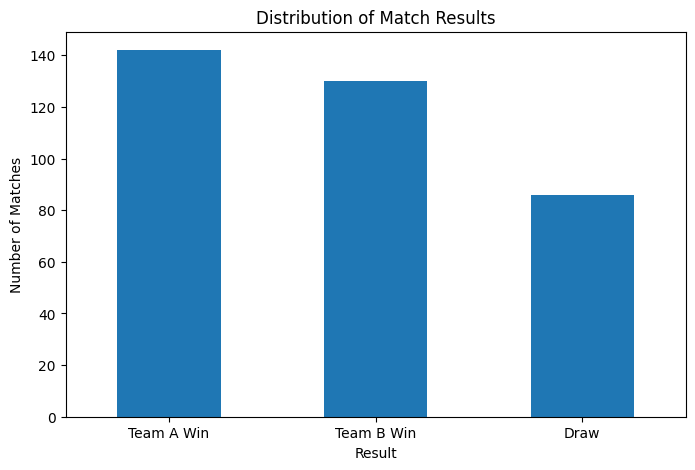

In [ ]:
result_counts = (
    matches_men["result"]
    .value_counts()
)

print(result_counts)

plt.figure(figsize=(8, 5))

result_counts.plot(
    kind="bar"
)

plt.title(
    "Distribution of Match Results"
)

plt.xlabel(
    "Result"
)

plt.ylabel(
    "Number of Matches"
)

plt.xticks(
    rotation=0
)

plt.show()

In [ ]:
goals_by_tournament = (
    matches_men
    .groupby(
        ["tournament", "year"]
    )
    .agg(
        matches=("result", "size"),
        total_goals=("total_goals", "sum"),
        avg_goals=("total_goals", "mean")
    )
    .reset_index()
)

display(
    goals_by_tournament
)

,tournament,year,matches,total_goals,avg_goals
0,European Championship,2020,51,142,2.784314
1,European Championship,2024,51,117,2.294118
2,World Cup,2010,64,145,2.265625
3,World Cup,2014,64,171,2.671875
4,World Cup,2018,64,169,2.640625
5,World Cup,2022,64,172,2.687500


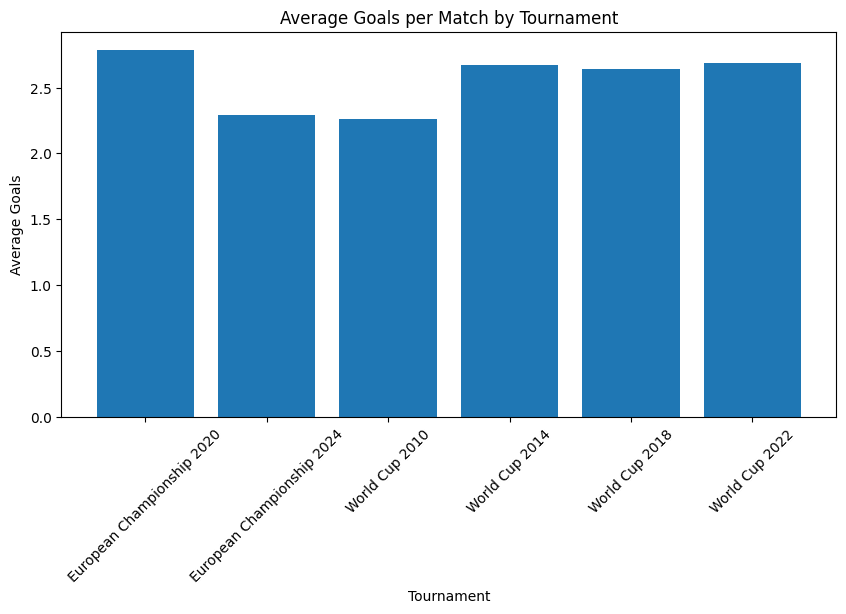

In [ ]:
labels = (
    goals_by_tournament["tournament"]
    + " "
    + goals_by_tournament["year"].astype(str)
)

plt.figure(figsize=(10, 5))

plt.bar(
    labels,
    goals_by_tournament["avg_goals"]
)

plt.title(
    "Average Goals per Match by Tournament"
)

plt.xlabel(
    "Tournament"
)

plt.ylabel(
    "Average Goals"
)

plt.xticks(
    rotation=45
)

plt.show()

In [ ]:
elo_result_summary = (
    model_data
    .groupby("result")
    ["elo_diff"]
    .agg([
        "mean",
        "median",
        "std"
    ])
)

display(
    elo_result_summary
)

,mean,median,std
result,,,
Draw,11.289119,15.000000,57.208574
Team A Win,24.276250,16.354788,56.695051
Team B Win,-9.871594,0.000000,59.854161


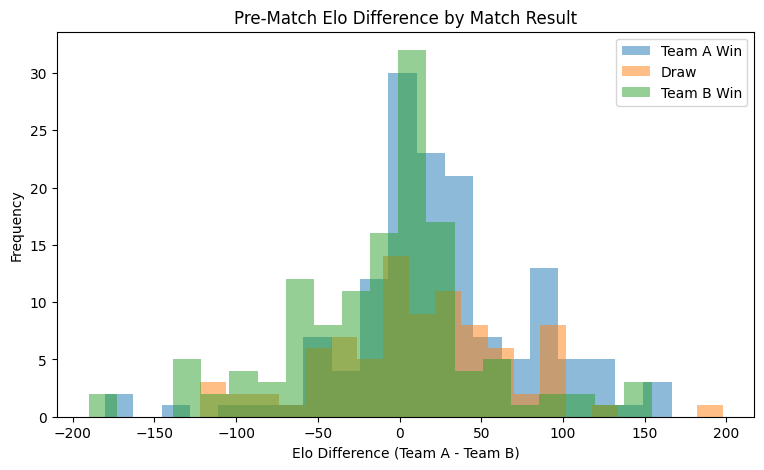

In [ ]:
plt.figure(figsize=(9, 5))

for result in [
    "Team A Win",
    "Draw",
    "Team B Win"
]:

    subset = model_data[
        model_data["result"] == result
    ]

    plt.hist(
        subset["elo_diff"],
        alpha=0.5,
        bins=20,
        label=result
    )

plt.title(
    "Pre-Match Elo Difference by Match Result"
)

plt.xlabel(
    "Elo Difference (Team A - Team B)"
)

plt.ylabel(
    "Frequency"
)

plt.legend()

plt.show()

In [ ]:
form_summary = (
    model_data
    .groupby("result")
    ["form_diff"]
    .agg([
        "mean",
        "median",
        "std"
    ])
)

display(
    form_summary
)

,mean,median,std
result,,,
Draw,0.214341,0.2,0.989491
Team A Win,0.377700,0.4,0.870828
Team B Win,-0.107051,0.0,0.912210


In [ ]:
feature_columns = [
    "elo_diff",
    "form_diff",
    "goals_for_diff",
    "goals_against_diff",
    "recent_goal_diff",
    "win_rate_diff",
    "is_knockout"
]

correlation_matrix = (
    model_data[
        feature_columns
    ]
    .corr()
)

display(
    correlation_matrix.round(2)
)

,elo_diff,form_diff,goals_for_diff,goals_against_diff,recent_goal_diff,win_rate_diff,is_knockout
elo_diff,1.00,0.66,0.49,-0.40,0.60,0.59,0.16
form_diff,0.66,1.00,0.66,-0.58,0.83,0.95,0.13
goals_for_diff,0.49,0.66,1.00,-0.12,0.75,0.63,0.08
goals_against_diff,-0.40,-0.58,-0.12,1.00,-0.74,-0.49,-0.08
recent_goal_diff,0.60,0.83,0.75,-0.74,1.00,0.75,0.11
win_rate_diff,0.59,0.95,0.63,-0.49,0.75,1.00,0.14
is_knockout,0.16,0.13,0.08,-0.08,0.11,0.14,1.00


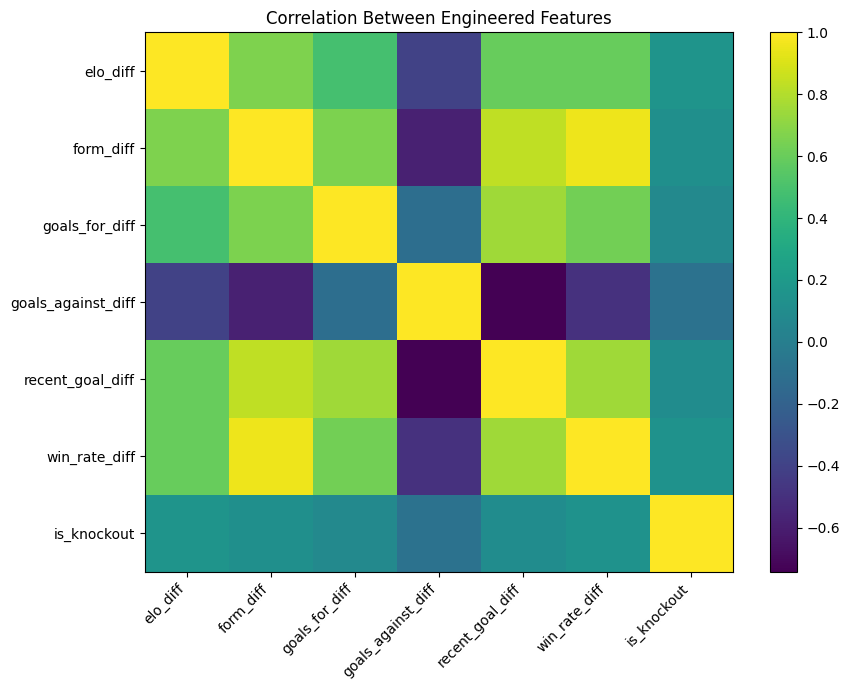

In [ ]:
plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(feature_columns)),
    feature_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(feature_columns)),
    feature_columns
)

plt.title(
    "Correlation Between Engineered Features"
)

plt.tight_layout()

plt.show()

In [ ]:
class_distribution = (
    model_data["target"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

class_table = pd.DataFrame({
    "target": [
        "Team B Win",
        "Draw",
        "Team A Win"
    ],
    "percentage": class_distribution.values
})

display(
    class_table
)

,target,percentage
0,Team B Win,36.312849
1,Draw,24.022346
2,Team A Win,39.664804


In [ ]:
MODEL_FEATURES = [
    "elo_a",
    "elo_b",
    "elo_diff",

    "form_points_a",
    "form_points_b",
    "form_diff",

    "avg_goals_for_a",
    "avg_goals_for_b",
    "goals_for_diff",

    "avg_goals_against_a",
    "avg_goals_against_b",
    "goals_against_diff",

    "avg_goal_diff_a",
    "avg_goal_diff_b",
    "recent_goal_diff",

    "win_rate_a",
    "win_rate_b",
    "win_rate_diff",

    "recent_games_a",
    "recent_games_b",

    "is_knockout"
]

print(
    "Number of model features:",
    len(MODEL_FEATURES)
)

print("\nFeatures:")

for feature in MODEL_FEATURES:
    print("-", feature)

Number of model features: 21

Features:
- elo_a
- elo_b
- elo_diff
- form_points_a
- form_points_b
- form_diff
- avg_goals_for_a
- avg_goals_for_b
- goals_for_diff
- avg_goals_against_a
- avg_goals_against_b
- goals_against_diff
- avg_goal_diff_a
- avg_goal_diff_b
- recent_goal_diff
- win_rate_a
- win_rate_b
- win_rate_diff
- recent_games_a
- recent_games_b
- is_knockout


In [ ]:
classification_data = model_data[
    [
        "date",
        "tournament",
        "year",
        "round",
        "team_a",
        "team_b"
    ]
    +
    MODEL_FEATURES
    +
    [
        "result",
        "target"
    ]
].copy()

print(
    "Classification dataset:",
    classification_data.shape
)

display(
    classification_data.head()
)

Classification dataset: (358, 29)


,date,tournament,year,round,team_a,team_b,elo_a,elo_b,elo_diff,form_points_a,form_points_b,form_diff,avg_goals_for_a,avg_goals_for_b,goals_for_diff,avg_goals_against_a,avg_goals_against_b,goals_against_diff,avg_goal_diff_a,avg_goal_diff_b,recent_goal_diff,win_rate_a,win_rate_b,win_rate_diff,recent_games_a,recent_games_b,is_knockout,result,target
0,2010-06-11,World Cup,2010,Matchday 1,South Africa,Mexico,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,Draw,1
1,2010-06-11,World Cup,2010,Matchday 1,Uruguay,France,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,Draw,1
2,2010-06-12,World Cup,2010,Matchday 2,South Korea,Greece,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,Team A Win,2
3,2010-06-12,World Cup,2010,Matchday 2,Argentina,Nigeria,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,Team A Win,2
4,2010-06-12,World Cup,2010,Matchday 2,England,USA,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,Draw,1


In [ ]:
poisson_data = model_data[
    [
        "date",
        "tournament",
        "year",
        "round",
        "team_a",
        "team_b"
    ]
    +
    MODEL_FEATURES
    +
    [
        "poisson_goals_a",
        "poisson_goals_b"
    ]
].copy()

print(
    "Poisson dataset:",
    poisson_data.shape
)

display(
    poisson_data.head()
)

Poisson dataset: (358, 29)


,date,tournament,year,round,team_a,team_b,elo_a,elo_b,elo_diff,form_points_a,form_points_b,form_diff,avg_goals_for_a,avg_goals_for_b,goals_for_diff,avg_goals_against_a,avg_goals_against_b,goals_against_diff,avg_goal_diff_a,avg_goal_diff_b,recent_goal_diff,win_rate_a,win_rate_b,win_rate_diff,recent_games_a,recent_games_b,is_knockout,poisson_goals_a,poisson_goals_b
0,2010-06-11,World Cup,2010,Matchday 1,South Africa,Mexico,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,1,1
1,2010-06-11,World Cup,2010,Matchday 1,Uruguay,France,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,0,0
2,2010-06-12,World Cup,2010,Matchday 2,South Korea,Greece,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,2,0
3,2010-06-12,World Cup,2010,Matchday 2,Argentina,Nigeria,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,1,0
4,2010-06-12,World Cup,2010,Matchday 2,England,USA,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,1,1


In [ ]:
print("=" * 60)
print("TEMPORAL DATA LEAKAGE CHECK")
print("=" * 60)

first_match = model_data.iloc[0]

print(
    "First match:",
    first_match["team_a"],
    "vs",
    first_match["team_b"]
)

print(
    "Team A pre-match Elo:",
    first_match["elo_a"]
)

print(
    "Team B pre-match Elo:",
    first_match["elo_b"]
)

print(
    "Team A previous games:",
    first_match["recent_games_a"]
)

print(
    "Team B previous games:",
    first_match["recent_games_b"]
)

assert first_match["elo_a"] == 1500
assert first_match["elo_b"] == 1500

assert first_match["recent_games_a"] == 0
assert first_match["recent_games_b"] == 0

print(
    "\nLeakage test passed."
)

TEMPORAL DATA LEAKAGE CHECK
First match: South Africa vs Mexico
Team A pre-match Elo: 1500.0
Team B pre-match Elo: 1500.0
Team A previous games: 0
Team B previous games: 0

Leakage test passed.


In [ ]:
print("=" * 60)
print("FEATURE ENGINEERING VALIDATION")
print("=" * 60)

print(
    "\nOriginal matches:",
    len(matches_men)
)

print(
    "Modeling observations:",
    len(model_data)
)

print(
    "Classification observations:",
    len(classification_data)
)

print(
    "Poisson observations:",
    len(poisson_data)
)

print(
    "\nMissing classification features:",
    classification_data[
        MODEL_FEATURES
    ].isna().sum().sum()
)

print(
    "Missing targets:",
    classification_data[
        "target"
    ].isna().sum()
)

print(
    "\nDate range:",
    model_data["date"].min(),
    "to",
    model_data["date"].max()
)

print(
    "\nNumber of teams:",
    len(
        set(model_data["team_a"])
        |
        set(model_data["team_b"])
    )
)

print(
    "\nNumber of predictors:",
    len(MODEL_FEATURES)
)

FEATURE ENGINEERING VALIDATION

Original matches: 358
Modeling observations: 358
Classification observations: 358
Poisson observations: 358

Missing classification features: 0
Missing targets: 0

Date range: 2010-06-11 00:00:00 to 2024-07-14 00:00:00

Number of teams: 64

Number of predictors: 21


In [ ]:
model_data.to_csv(
    "mens_modeling_dataset.csv",
    index=False
)

classification_data.to_csv(
    "mens_classification_dataset.csv",
    index=False
)

poisson_data.to_csv(
    "mens_poisson_dataset.csv",
    index=False
)

elo_table.to_csv(
    "mens_final_elo.csv",
    index=False
)

print(
    "Notebook 2 outputs saved successfully."
)

Notebook 2 outputs saved successfully.


## Feature Engineering Summary

The historical match dataset was processed chronologically to ensure that
all predictors represented information available before each match.

An Elo rating system was constructed directly from the historical tournament
results. Each team began with an Elo rating of 1500, and ratings were updated
only after the corresponding match features had been recorded.

Recent-performance features were calculated using each team's previous five
tournament matches. These features included recent points earned, goals
scored, goals conceded, goal difference, and win rate.

The final modeling dataset also includes the difference between the two teams'
ratings and performance statistics, as well as an indicator distinguishing
group-stage and knockout matches.

Separate target variables were retained for the two modeling approaches.
Classification models predict Team A win, draw, or Team B win, while the
Poisson model predicts the number of goals scored by each team.

All rolling statistics and Elo ratings use only matches occurring before the
match being predicted, reducing the risk of temporal data leakage.